# **World Model - Memory *(M)*** 

This notebook implements the Memory component of a World Model framework. The Memory module uses a combination of recurrent neural networks and mixture density networks to predict future states based on current observations and actions.

### **Workflow Overview**
- **Data Generation and Processing:** Collect state-action sequences from environment interactions
- **Latent Vector Extraction:** Convert raw observations into compact latent representations (z)
- **Dataset Creation:** Prepare sequential data for MDN-RNN training
- **MDN-RNN Model Implementation:** Build and train the predictive memory model
- **Visualization and Evaluation:** Analyze model performance through reconstructions

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### **1. Data Preparation: World Model Dataset**
---

In [11]:
import os
import h5py
import torch
import numpy as np
from tqdm import tqdm
from torchvision import transforms

def precompute_latents(
    vae,
    input_h5_path='car_racing_data.h5',
    output_h5_path='car_racing_latents.h5',
    batch_size=32
):
    """
    Precompute latents for all episodes and save to a new HDF5 file.
    
    Args:
        vae: Trained VAE model
        input_h5_path: Path to original dataset with images
        output_h5_path: Path where latents will be saved
        batch_size: Number of images to encode at once
    """

    # Create the output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_h5_path), exist_ok=True)
    
    # Setup
    vae.eval()
    vae = vae.to(DEVICE)
    transform = transforms.ToTensor()
    
    # Open input file to get dimensions
    with h5py.File(input_h5_path, 'r') as h5f_in:
        num_episodes = h5f_in['images'].shape[0]
        max_steps    = h5f_in['images'].shape[1]
        action_dim   = 1
        
        print(f"Found {num_episodes} episodes with up to {max_steps} steps each")
        print(f"Action dimension: {action_dim}")
        
        # Get latent dimension by running a single forward pass
        sample_img = h5f_in['images'][0, 0]
        sample_tensor = transform(sample_img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            mu, logvar = vae.encode(sample_tensor)
            z_dim = mu.shape[1]
        print(f"Latent dimension: {z_dim}")
    
    # Create output HDF5 file
    with h5py.File(output_h5_path, 'w') as h5f_out:
        # Create datasets with known shapes
        # We'll use variable-length datasets since episodes may have different lengths
        z_dtype = np.float32
        action_dtype = np.float32
        reward_dtype = np.float32
        done_dtype = np.float32
        
        # Create datasets to store variable-length sequences
        z_dataset = h5f_out.create_dataset(
            'z', 
            (num_episodes, max_steps, z_dim),
            dtype=z_dtype,
            chunks=True,
            compression='gzip',
            compression_opts=4
        )
        
        z_next_dataset = h5f_out.create_dataset(
            'z_next',
            (num_episodes, max_steps, z_dim),
            dtype=z_dtype,
            chunks=True,
            compression='gzip',
            compression_opts=4
        )
        
        actions_dataset = h5f_out.create_dataset(
            'actions',
            (num_episodes, max_steps, action_dim),
            dtype=action_dtype,
            chunks=True,
            compression='gzip',
            compression_opts=4
        )
        
        rewards_dataset = h5f_out.create_dataset(
            'rewards',
            (num_episodes, max_steps),
            dtype=reward_dtype,
            chunks=True,
            compression='gzip',
            compression_opts=4
        )
        
        dones_dataset = h5f_out.create_dataset(
            'dones',
            (num_episodes, max_steps),
            dtype=done_dtype,
            chunks=True,
            compression='gzip',
            compression_opts=4
        )
        
        # Store metadata
        h5f_out.attrs['num_episodes'] = num_episodes
        h5f_out.attrs['max_steps'] = max_steps
        h5f_out.attrs['z_dim'] = z_dim
        h5f_out.attrs['action_dim'] = action_dim
    
    # Process episodes one by one
    with h5py.File(input_h5_path, 'r') as h5f_in:
        with h5py.File(output_h5_path, 'a') as h5f_out:
            
            for episode_idx in tqdm(range(num_episodes), desc="Encoding episodes"):
                # Load episode data
                images = h5f_in['images'][episode_idx]
                actions = h5f_in['actions'][episode_idx]
                rewards = h5f_in['rewards'][episode_idx]
                dones = h5f_in['dones'][episode_idx]
                
                # Find actual episode length (where done=1 or end of sequence)
                # Assuming done=1 at the end of each episode
                episode_length = len(images)
                # If there's a done flag in the middle, you might truncate earlier
                # For simplicity, we'll use the full length
                
                # Encode images in batches to avoid memory issues
                all_z = []
                
                for start_idx in range(0, episode_length, batch_size):
                    end_idx = min(start_idx + batch_size, episode_length)
                    batch_images = images[start_idx:end_idx]
                    
                    # Convert batch of images to tensors
                    batch_tensors = torch.stack([
                        transform(img) for img in batch_images
                    ]).to(DEVICE)
                    
                    # Encode
                    with torch.no_grad():
                        mu, logvar = vae.encode(batch_tensors)
                        z_batch = vae.reparameterize(mu, logvar)
                    
                    all_z.append(z_batch.cpu().numpy())
                
                # Concatenate all batches
                z_full = np.concatenate(all_z, axis=0)  # Shape: (episode_length, z_dim)
                
                # Create shifted versions (z_t and z_{t+1})
                z = z_full[:-1]  # All except last
                z_next = z_full[1:]  # All except first
                # actions_shifted = actions[:-1]
                actions_shifted = np.expand_dims(actions, 1)[:-1]
                rewards_shifted = rewards[:-1]
                dones_shifted = dones[:-1]
                
                # Store in datasets (pad with zeros for unused steps)
                seq_len = len(z)
                h5f_out['z'][episode_idx, :seq_len]       = z
                h5f_out['z_next'][episode_idx, :seq_len]  = z_next
                h5f_out['actions'][episode_idx, :seq_len] = actions_shifted
                h5f_out['rewards'][episode_idx, :seq_len] = rewards_shifted
                h5f_out['dones'][episode_idx, :seq_len]   = dones_shifted
                
                # Store actual sequence length as an attribute for this episode
                h5f_out[f'episode_{episode_idx}_length'] = seq_len
    
            print(f"Precomputation complete! Saved to {output_h5_path}")

In [12]:
from jepacartpole.models import VAE
from jepacartpole.config import ConfigVAE

vae_config = ConfigVAE()
vae_model = VAE(vae_config).to(DEVICE)
vae_model.load_state_dict(torch.load('../checkpoints/vae.pth', weights_only=False, map_location=DEVICE))

precompute_latents(vae_model, input_h5_path='../data/vae/vae_data.h5', output_h5_path='../data/jepa/jepa.h5', batch_size=8)

Found 128 episodes with up to 500 steps each
Action dimension: 1
Latent dimension: 8


Encoding episodes:   0%|          | 0/128 [00:00<?, ?it/s]

Encoding episodes: 100%|██████████| 128/128 [02:42<00:00,  1.27s/it]

Precomputation complete! Saved to ../data/jepa/jepa.h5


In [1]:
# JEPA dataset class
import h5py
import torch
import numpy as np
from torch.utils.data import Dataset
from typing import Tuple, Optional, List

class JEPADataset(Dataset):
    """
    Dataset for JEPA training that loads precomputed latents.
    
    Returns transitions (z_t, action_t, z_{t+1}) for each timestep.
    """
    
    def __init__(
        self, 
        h5_path='../data/jepa/jepa.h5'
    ):
        """
        Args:
            h5_path: Path to precomputed latents HDF5 file
        """
        self.h5_path = h5_path
        
        # Open HDF5 to get metadata
        with h5py.File(self.h5_path, 'r') as h5f:
            self.num_episodes = h5f.attrs['num_episodes']
            self.max_steps = h5f.attrs['max_steps']
            self.z_dim = h5f.attrs['z_dim']
            self.action_dim = h5f.attrs['action_dim']

            self.transition_indices = []
            self.episode_lengths = []
            for ep_idx in range(self.num_episodes):
                length = h5f[f'episode_{ep_idx}_length'][()]
                self.episode_lengths.append(length)
                
                # Single transitions: each step is a sample
                for step_idx in range(length):
                    self.transition_indices.append((ep_idx, step_idx))
        
        self.h5_file = None
        
        print(f"Initialized JEPADataset with:")
        print(f"  - {len(self.transition_indices)} total transitions")
        print(f"  - Latent dimension: {self.z_dim}")
        print(f"  - Action dimension: {self.action_dim}")

    def __len__(self):
        return self.num_episodes
    
    def __getitem__(self, idx):
        """
        Returns:
            tuple (z_t, action_t, z_{t+1}, reward_t, done_t)
        """

        ep_idx, start_idx = self.transition_indices[idx]

        if self.h5_file is None:
            self.h5_file = h5py.File(self.h5_path, 'r')

        length = self.episode_lengths[ep_idx]
        z_ep = self.h5_file['z'][ep_idx, :length]
        z_next_ep = self.h5_file['z_next'][ep_idx, :length]
        actions_ep = self.h5_file['actions'][ep_idx, :length]
        rewards_ep = self.h5_file['rewards'][ep_idx, :length]
        dones_ep = self.h5_file['dones'][ep_idx, :length]
        
        # Convert to tensors
        z_ep = torch.from_numpy(z_ep).float()
        z_next_ep = torch.from_numpy(z_next_ep).float()
        actions_ep = torch.from_numpy(actions_ep).float()
        rewards_ep = torch.from_numpy(rewards_ep).float()
        dones_ep = torch.from_numpy(dones_ep).float()

        # Single transition
        z_t = z_ep[start_idx]
        action_t = actions_ep[start_idx]
        z_next = z_next_ep[start_idx]
        reward_t = rewards_ep[start_idx]
        done_t = dones_ep[start_idx]
        
        return z_t, action_t, z_next, reward_t, done_t
    
    def __del__(self):
        if self.h5_file is not None:
            self.h5_file.close()

## **2. JEPA Model Architecture**
---

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ============================================
# 1. DEFINE THE PREDICTOR MODEL
# ============================================

class JEPAPredictor(nn.Module):
    """
    Simple MLP predictor that maps (z_t, action_t) -> z_{t+1}
    """
    def __init__(self, z_dim, action_dim, hidden_dim=128):
        super(JEPAPredictor, self).__init__()
        
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        # Input size: latent + action
        input_dim = z_dim + action_dim
        
        # Simple 3-layer MLP
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, z_dim)
        )
    
    def forward(self, z, action):
        # Concatenate z and action
        x = torch.cat([z, action], dim=-1)
        return self.net(x)

Using device: cuda


Initialized JEPADataset with:
  - 63872 total transitions
  - Latent dimension: 8
  - Action dimension: 1
Dataset size: 128 transitions
z_dim: 8, action_dim: 1
Model has 18,824 parameters

Starting training...


Epoch 1/10:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/10: 100%|██████████| 1/1 [00:00<00:00,  1.72it/s, loss=3.53]


Epoch 1 average loss: 3.529011


Epoch 2/10: 100%|██████████| 1/1 [00:00<00:00,  1.73it/s, loss=3.28]


...

Epoch 8 average loss: 1.879899


Epoch 9/10: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s, loss=1.65]


Epoch 9 average loss: 1.647195


Epoch 10/10: 100%|██████████| 1/1 [00:00<00:00,  1.68it/s, loss=1.42]


Epoch 10 average loss: 1.420238


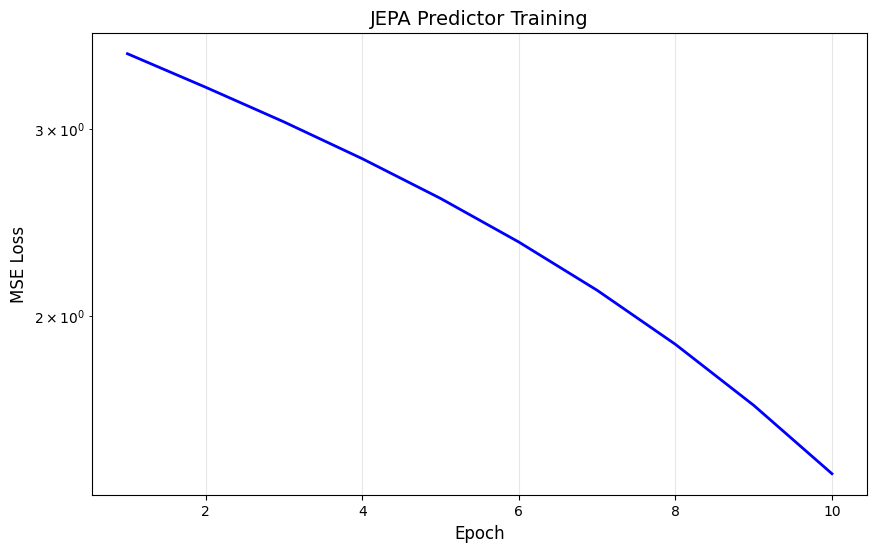


Final training loss: 1.420238

Model saved to 'checkpoints/jepa_predictor.pth'


In [6]:
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Create dataloader
batch_size = 256
dataset = JEPADataset()
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Get dimensions from the dataset
z_dim = dataset.z_dim
action_dim = dataset.action_dim

print(f"Dataset size: {len(dataset)} transitions")
print(f"z_dim: {z_dim}, action_dim: {action_dim}")

# ============================================
# 3. INITIALIZE MODEL, OPTIMIZER, LOSS
# ============================================

jepa = JEPAPredictor(z_dim, action_dim).to(DEVICE)
optimizer = optim.Adam(jepa.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"Model has {sum(p.numel() for p in jepa.parameters()):,} parameters")

# ============================================
# 4. TRAINING LOOP
# ============================================

num_epochs = 10
train_losses = []

print("\nStarting training...")
for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    
    # Progress bar for this epoch
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for z_t, action_t, z_next, reward, done in pbar:
        # Move to device
        z_t = z_t.to(DEVICE)
        action_t = action_t.to(DEVICE)
        z_next = z_next.to(DEVICE)
        
        # Forward pass
        z_pred = jepa(z_t, action_t)
        
        # Compute loss
        loss = criterion(z_pred, z_next)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track loss
        epoch_loss += loss.item()
        num_batches += 1
        
        # Update progress bar
        pbar.set_postfix({'loss': loss.item()})
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1} average loss: {avg_loss:.6f}")

# ============================================
# 5. PLOT TRAINING CURVE
# ============================================

plt.figure(figsize=(10, 6))
plt.plot([x for x in range(1, num_epochs+1)], train_losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('JEPA Predictor Training', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale often helps see progress
plt.show()

print(f"\nFinal training loss: {train_losses[-1]:.6f}")

# ============================================
# 6. SAVE THE MODEL (Optional)
# ============================================

torch.save({
    'model_state_dict': jepa.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'z_dim': z_dim,
    'action_dim': action_dim
}, '../checkpoints/jepa_predictor.pth')

print("\nModel saved to 'checkpoints/jepa_predictor.pth'")